# Probing on Patching Data: Bridging Experiment 1 and 2

This notebook applies **layerwise linear probing** to the sentence format from the activation patching experiment.

**Setup:** `Name1 <verb> Name2. The one who <verb> was` (or passive equivalent)

**Probe position:** The final token ("was") — the same position used for patching.

**Classification task:** Does the model's hidden state at the "was" token encode whether **Name1** or **Name2** is the correct answer?
- Class 0: Name1 (first name in sentence) is correct
- Class 1: Name2 (second name in sentence) is correct

**Goal:** Bridge the probing experiment (Exp 1, where role info peaks at layer ~5) with the patching experiment (Exp 2, where causal effects peak at layers 17-25). If accuracy rises in later layers, it suggests the model is actively *routing* role information toward the output at those layers.

In [1]:
!nvidia-smi

import torch
print(f'torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Sun Apr 19 13:15:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install transformers torch accelerate bitsandbytes matplotlib scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 21.3 MB/s eta 0:00:00:00:0100:01


In [3]:
from getpass import getpass
from huggingface_hub import login

token = getpass('Paste your Hugging Face read token: ').strip()
login(token=token, add_to_git_credential=False)
print('Authenticated.')

Authenticated.


In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
import sys

## 1. Load Model and Tokenizer

In [5]:
MODEL_NAME = 'CohereForAI/aya-expanse-8b'

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print('Loading model in fp16 (with hidden states)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    torch_dtype=torch.float16,
    device_map='auto',
)
model.eval()
print('Model loaded.')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

N_LAYERS = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
print(f'N_LAYERS = {N_LAYERS}, HIDDEN_SIZE = {HIDDEN_SIZE}')

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded.
Device: cuda
N_LAYERS = 32, HIDDEN_SIZE = 4096


## 2. Find Single-Token Names

We need names that are single tokens (with leading space) so the correct/incorrect answer is always a single token.

In [92]:
candidate_names = [
    'Emma', 'Bob', 'John', 'Mary', 'Tom', 'Lisa',
    'Paul', 'Alice', 'David', 'Sarah', 'James', 'Anna',
    'Mark', 'Jane', 'Luke', 'Kate', 'Sam', 'Amy',
    'Peter', 'Susan', 'Frank', 'Helen', 'Carl', 'Grace',
    'Max', 'Rose', 'Adam', 'Julia', 'Eric', 'Laura',
    'Dan', 'Ruth', 'Ben', 'Lily', 'Jack', 'Jill',
    'Hank', 'Noah', 'Leo', 'Mia', 'Dean', 'Liam',
    'Owen', 'Ella', 'Hugo', 'Zoe', 'Cole', 'Eve',
    'Ken', 'Meg', 'Ray', 'Joy', 'Lee', 'Kay',
    'Roy', 'Finn', 'Jade', 'Beth', 'Phil', 'Will',
    'Fay', 'Ian', 'Ned', 'Glen', 'Troy', 'Dawn',
    'Dale', 'Gail', 'Brent', 'Blair', 'Reed', 'Sky',
]

print('Checking which names are single-token (with leading space):')
print()
single_token_names = []
for name in candidate_names:
    tokens = tokenizer.encode(f' {name}', add_special_tokens=False)
    n_tok = len(tokens)

    status = 'SINGLE' if n_tok == 1 else f'MULTI ({n_tok})'
    print(f'  {name:10s} -> {status}  token_ids={tokens}')
    if n_tok == 1:
        single_token_names.append(name)

print()
print(f'Single-token names ({len(single_token_names)}): {single_token_names}')

Checking which names are single-token (with leading space):

  Emma       -> SINGLE  token_ids=[28940]
  Bob        -> SINGLE  token_ids=[9352]
  John       -> SINGLE  token_ids=[3439]
  Mary       -> SINGLE  token_ids=[7382]
  Tom        -> SINGLE  token_ids=[6253]
  Lisa       -> SINGLE  token_ids=[26509]
  Paul       -> SINGLE  token_ids=[4822]
  Alice      -> SINGLE  token_ids=[21287]
  David      -> SINGLE  token_ids=[5759]
  Sarah      -> SINGLE  token_ids=[19306]
  James      -> SINGLE  token_ids=[6016]
  Anna       -> SINGLE  token_ids=[14578]
  Mark       -> SINGLE  token_ids=[5715]
  Jane       -> SINGLE  token_ids=[10225]
  Luke       -> SINGLE  token_ids=[25568]
  Kate       -> SINGLE  token_ids=[25917]
  Sam        -> SINGLE  token_ids=[6009]
  Amy        -> SINGLE  token_ids=[29552]
  Peter      -> SINGLE  token_ids=[7357]
  Susan      -> SINGLE  token_ids=[28193]
  Frank      -> SINGLE  token_ids=[6982]
  Helen      -> SINGLE  token_ids=[26926]
  Carl       -> SINGLE  to

## 3. Build Dataset

Each name pair uses **fresh names** that don't appear in any other pair, plus a **unique verb**.

For each (Name1, Name2, verb) we create 2 orderings × 4 sentence types = **8 examples per pair**.

| Type | Prompt | Correct answer |
|------|--------|----------------|
| 1 | `Name1 <verb> Name2. The one who <verb> was` | Name1 |
| 2 | `Name1 was <verb> by Name2. The one who <verb> was` | Name2 |
| 3 | `Name1 <verb> Name2. The one being <verb> was` | Name2 |
| 4 | `Name1 was <verb> by Name2. The one being <verb> was` | Name1 |

**Label:** `Name1_correct` (types 1, 4) vs `Name2_correct` (types 2, 3) — balanced by construction.

In [93]:
# Each name appears in EXACTLY ONE pair. Each pair gets a unique verb.
# This eliminates any name-identity confound.
from collections import Counter

# Expanded verb pool — each pair gets its own verb
verb_pool = [
    'warned', 'helped', 'pushed', 'stopped', 'called', 'saved', 'followed',
    'praised', 'blamed', 'chased', 'grabbed', 'missed', 'thanked', 'tricked',
    'caught', 'fooled', 'scared', 'touched', 'found', 'heard', 'joined',
    'reached', 'taught', 'hurt', 'loved', 'hated', 'kicked', 'watched',
    'trained', 'fed',
]

# Pair names: take consecutive pairs from single_token_names
# Each name used exactly once
# Cap at 19 pairs → 19 × 8 = 152 examples
n_pairs = min(len(single_token_names) // 2, len(verb_pool), 19)
names_to_use = single_token_names[:n_pairs * 2]

pairs_with_verbs = []
for i in range(n_pairs):
    a = names_to_use[2 * i]
    b = names_to_use[2 * i + 1]
    v = verb_pool[i]
    pairs_with_verbs.append((a, b, v))

print(f'Single-token names available: {len(single_token_names)}')
print(f'Using {len(names_to_use)} names in {n_pairs} pairs (each name used once)')
print(f'Unique verbs: {n_pairs}')
print(f'Examples per pair: 8 (2 orderings × 4 types)')
print(f'Total examples: {n_pairs * 8}')
print()
print('Pairs:')
for i, (a, b, v) in enumerate(pairs_with_verbs):
    print(f'  Pair {i+1:2d}: {a:8s} & {b:8s}  verb={v}')

# Build all examples: for each pair, both orderings, 4 sentence types
examples = []
for name_a, name_b, verb in pairs_with_verbs:
    for name1, name2 in [(name_a, name_b), (name_b, name_a)]:
        # Type 1: active, agent question -> Name1 correct
        examples.append({
            'prompt': f'{name1} {verb} {name2}. The one who {verb} was',
            'correct_name': name1,
            'incorrect_name': name2,
            'label': 'Name1_correct',
            'type': 'active_agent',
            'name1': name1, 'name2': name2, 'verb': verb,
        })
        # Type 2: passive, agent question -> Name2 correct
        examples.append({
            'prompt': f'{name1} was {verb} by {name2}. The one who {verb} was',
            'correct_name': name2,
            'incorrect_name': name1,
            'label': 'Name2_correct',
            'type': 'passive_agent',
            'name1': name1, 'name2': name2, 'verb': verb,
        })
        # Type 3: active, patient question -> Name2 correct
        examples.append({
            'prompt': f'{name1} {verb} {name2}. The one being {verb} was',
            'correct_name': name2,
            'incorrect_name': name1,
            'label': 'Name2_correct',
            'type': 'active_patient',
            'name1': name1, 'name2': name2, 'verb': verb,
        })
        # Type 4: passive, patient question -> Name1 correct
        examples.append({
            'prompt': f'{name1} was {verb} by {name2}. The one being {verb} was',
            'correct_name': name1,
            'incorrect_name': name2,
            'label': 'Name1_correct',
            'type': 'passive_patient',
            'name1': name1, 'name2': name2, 'verb': verb,
        })

# Precompute token IDs
for ex in examples:
    ex['correct_id'] = tokenizer.encode(f' {ex["correct_name"]}', add_special_tokens=False)[0]
    ex['incorrect_id'] = tokenizer.encode(f' {ex["incorrect_name"]}', add_special_tokens=False)[0]

n1_count = sum(1 for ex in examples if ex['label'] == 'Name1_correct')
n2_count = sum(1 for ex in examples if ex['label'] == 'Name2_correct')
assert n1_count == n2_count, f'Expected balanced, got {n1_count}/{n2_count}'
print(f'\nTotal examples: {len(examples)}')
print(f'  Name1_correct: {n1_count}')
print(f'  Name2_correct: {n2_count}')
print(f'  Balanced: {n1_count == n2_count}')

# Verify each name appears exactly 8 times (4 as correct, 4 as incorrect)
name_counts = Counter()
for ex in examples:
    name_counts[ex['name1']] += 1
    name_counts[ex['name2']] += 1
print(f'\nExamples per name (should all be 8):')
for name in names_to_use:
    print(f'  {name:8s}: {name_counts[name]} examples')

# Print the FULL dataset
print(f'\n{"="*100}')
print(f'FULL DATASET ({len(examples)} examples)')
print(f'{"="*100}')
for i, ex in enumerate(examples):
    print(f'[{i:3d}] {ex["label"]:15s} correct={ex["correct_name"]:6s} | {ex["prompt"]}')

Single-token names available: 72
Using 38 names in 19 pairs (each name used once)
Unique verbs: 19
Examples per pair: 8 (2 orderings × 4 types)
Total examples: 152

Pairs:
  Pair  1: Emma     & Bob       verb=warned
  Pair  2: John     & Mary      verb=helped
  Pair  3: Tom      & Lisa      verb=pushed
  Pair  4: Paul     & Alice     verb=stopped
  Pair  5: David    & Sarah     verb=called
  Pair  6: James    & Anna      verb=saved
  Pair  7: Mark     & Jane      verb=followed
  Pair  8: Luke     & Kate      verb=praised
  Pair  9: Sam      & Amy       verb=blamed
  Pair 10: Peter    & Susan     verb=chased
  Pair 11: Frank    & Helen     verb=grabbed
  Pair 12: Carl     & Grace     verb=missed
  Pair 13: Max      & Rose      verb=thanked
  Pair 14: Adam     & Julia     verb=tricked
  Pair 15: Eric     & Laura     verb=caught
  Pair 16: Dan      & Ruth      verb=fooled
  Pair 17: Ben      & Lily      verb=scared
  Pair 18: Jack     & Jill      verb=touched
  Pair 19: Hank     & Noah   

## 4. Baseline Validation (Informational)

Check how many examples the model gets right at the output level. **All examples are used for probing regardless** — we don't want to bias the probe toward representations that already encode the correct answer.

In [39]:
def compute_logit_diff(prompt, correct_id, incorrect_id):
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0, -1, :]
    return (logits[correct_id] - logits[incorrect_id]).item()

print('Baseline validation (correct name should have higher logit)...')
print('NOTE: All examples are used for probing regardless of baseline performance.')
print()

pass_count = 0
fail_count = 0

for i, ex in enumerate(examples):
    ld = compute_logit_diff(ex['prompt'], ex['correct_id'], ex['incorrect_id'])
    ex['logit_diff'] = ld  # store for reference
    
    if ld > 0:
        pass_count += 1
    else:
        fail_count += 1
        if fail_count <= 10:  # only print first 10 failures
            print(f'  FAIL [{i:3d}] ld={ld:+.2f} correct={ex["correct_name"]} | {ex["prompt"]}')
    
    if (i + 1) % 50 == 0:
        print(f'  Checked {i+1}/{len(examples)}...')

print(f'\nBaseline accuracy: {pass_count} / {len(examples)}  ({pass_count/len(examples)*100:.1f}%)')
print(f'  Pass: {pass_count}, Fail: {fail_count}')
if fail_count > 10:
    print(f'  ({fail_count - 10} more failures not shown)')
print(f'\nAll {len(examples)} examples will be used for probing (no filtering).')

Baseline validation (correct name should have higher logit)...
NOTE: All examples are used for probing regardless of baseline performance.

  FAIL [ 25] ld=-1.72 correct=Tom | Emma was stopped by Tom. The one who stopped was
  FAIL [ 29] ld=-1.58 correct=Emma | Tom was stopped by Emma. The one who stopped was
  FAIL [ 40] ld=-1.19 correct=Emma | Emma saved Paul. The one who saved was
  Checked 50/152...
  FAIL [ 51] ld=-0.81 correct=Bob | Bob was followed by John. The one being followed was
  FAIL [ 81] ld=-0.58 correct=Paul | Bob was stopped by Paul. The one who stopped was
  FAIL [ 85] ld=-1.42 correct=Bob | Paul was stopped by Bob. The one who stopped was
  Checked 100/152...
  FAIL [105] ld=-0.62 correct=Lisa | John was followed by Lisa. The one who followed was
  FAIL [107] ld=-1.70 correct=John | John was followed by Lisa. The one being followed was
  FAIL [118] ld=-0.27 correct=John | Paul warned John. The one being warned was
  FAIL [137] ld=-0.81 correct=Paul | Mary was stoppe

## 5. Extract Hidden States at "was" Token (All Layers)

For each example, run one forward pass and cache the hidden state at position -1 (the "was" token) from every layer.

In [94]:
n_examples = len(examples)
print(f'Extracting hidden states for {n_examples} examples across {N_LAYERS + 1} layers...')
print()

# layer_X[layer_idx] will be a list of vectors, then stacked into arrays
layer_X = {i: [] for i in range(N_LAYERS + 1)}  # 0 = embedding, 1..N_LAYERS = transformer layers
labels = []

for i, ex in enumerate(examples):
    inputs = tokenizer(ex['prompt'], return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # outputs.hidden_states: tuple of (N_LAYERS + 1) tensors, each (1, seq_len, hidden_size)
    for layer_idx in range(N_LAYERS + 1):
        vec = outputs.hidden_states[layer_idx][0, -1, :].float().cpu().numpy()
        layer_X[layer_idx].append(vec)
    
    labels.append(ex['label'])
    
    if (i + 1) % 50 == 0 or (i + 1) == n_examples:
        print(f'  Processed {i+1}/{n_examples}')

# Stack into arrays
for layer_idx in layer_X:
    layer_X[layer_idx] = np.array(layer_X[layer_idx])

labels = np.array(labels)

print(f'\nExtraction complete.')
print(f'Feature shape per layer: {layer_X[0].shape}')
print(f'Labels shape: {labels.shape}')
print(f'Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}')

Extracting hidden states for 152 examples across 33 layers...

  Processed 50/152
  Processed 100/152
  Processed 150/152
  Processed 152/152

Extraction complete.
Feature shape per layer: (152, 4096)
Labels shape: (152,)
Label distribution: {np.str_('Name1_correct'): np.int64(76), np.str_('Name2_correct'): np.int64(76)}


## 6. Layerwise Probing

Train a logistic regression probe at each layer to classify Name1_correct vs Name2_correct.

Use stratified train/test split + 5-fold cross-validation on the training set.

In [95]:
le = LabelEncoder()
y_enc = le.fit_transform(labels)  # Name1_correct=0, Name2_correct=1
print(f'Label encoding: {list(zip(le.classes_, range(len(le.classes_))))}')

# Train/test split
n_total = len(y_enc)
n_test = max(int(0.2 * n_total), 10)  # ~20% for test
n_train = n_total - n_test

train_idx, test_idx = train_test_split(
    np.arange(n_total),
    train_size=n_train,
    test_size=n_test,
    random_state=42,
    stratify=y_enc,
)

print(f'Total: {n_total}, Train: {n_train}, Test: {n_test}')
print(f'Train class dist: {dict(zip(*np.unique(y_enc[train_idx], return_counts=True)))}')
print(f'Test  class dist: {dict(zip(*np.unique(y_enc[test_idx], return_counts=True)))}')

# Probe each layer
# NOTE: C=0.001 (strong regularization) to prevent overfitting with 4096 features on small datasets.
# StandardScaler ensures regularization acts uniformly across features.
layer_results = {}
cv_folds = 5
c_value = 0.0001

print(f'\nProbing {N_LAYERS + 1} layers (5-fold CV + held-out test, C={c_value})...')
print()

for layer_idx in range(N_LAYERS + 1):
    X = layer_X[layer_idx]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
    
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42, C=c_value),
    )
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv_folds, scoring='accuracy')
    
    clf.fit(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    
    layer_results[layer_idx] = {
        'cv_accuracy': float(cv_scores.mean()),
        'cv_std': float(cv_scores.std()),
        'test_accuracy': test_acc,
    }
    
    print(f'Layer {layer_idx:3d}: CV = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}, Test = {test_acc:.4f}')

best_cv = max(layer_results, key=lambda k: layer_results[k]['cv_accuracy'])
best_test = max(layer_results, key=lambda k: layer_results[k]['test_accuracy'])
print(f'\nBest layer (CV):   {best_cv} ({layer_results[best_cv]["cv_accuracy"]:.4f})')
print(f'Best layer (test): {best_test} ({layer_results[best_test]["test_accuracy"]:.4f})')

Label encoding: [(np.str_('Name1_correct'), 0), (np.str_('Name2_correct'), 1)]
Total: 152, Train: 122, Test: 30
Train class dist: {np.int64(0): np.int64(61), np.int64(1): np.int64(61)}
Test  class dist: {np.int64(0): np.int64(15), np.int64(1): np.int64(15)}

Probing 33 layers (5-fold CV + held-out test, C=0.0001)...

Layer   0: CV = 0.4920 ± 0.0098, Test = 0.5000
Layer   1: CV = 0.3190 ± 0.0620, Test = 0.2333
Layer   2: CV = 0.3430 ± 0.1036, Test = 0.2333
Layer   3: CV = 0.4583 ± 0.0649, Test = 0.2667
Layer   4: CV = 0.4583 ± 0.0649, Test = 0.3333
Layer   5: CV = 0.4660 ± 0.0875, Test = 0.3667
Layer   6: CV = 0.4327 ± 0.1002, Test = 0.3667
Layer   7: CV = 0.4820 ± 0.1148, Test = 0.3667
Layer   8: CV = 0.5237 ± 0.0955, Test = 0.4000
Layer   9: CV = 0.5647 ± 0.1265, Test = 0.4333
Layer  10: CV = 0.5650 ± 0.1406, Test = 0.4333
Layer  11: CV = 0.6313 ± 0.1349, Test = 0.5000
Layer  12: CV = 0.7213 ± 0.1308, Test = 0.7000
Layer  13: CV = 0.7457 ± 0.1297, Test = 0.7667
Layer  14: CV = 0.7453 

## 7. Visualization

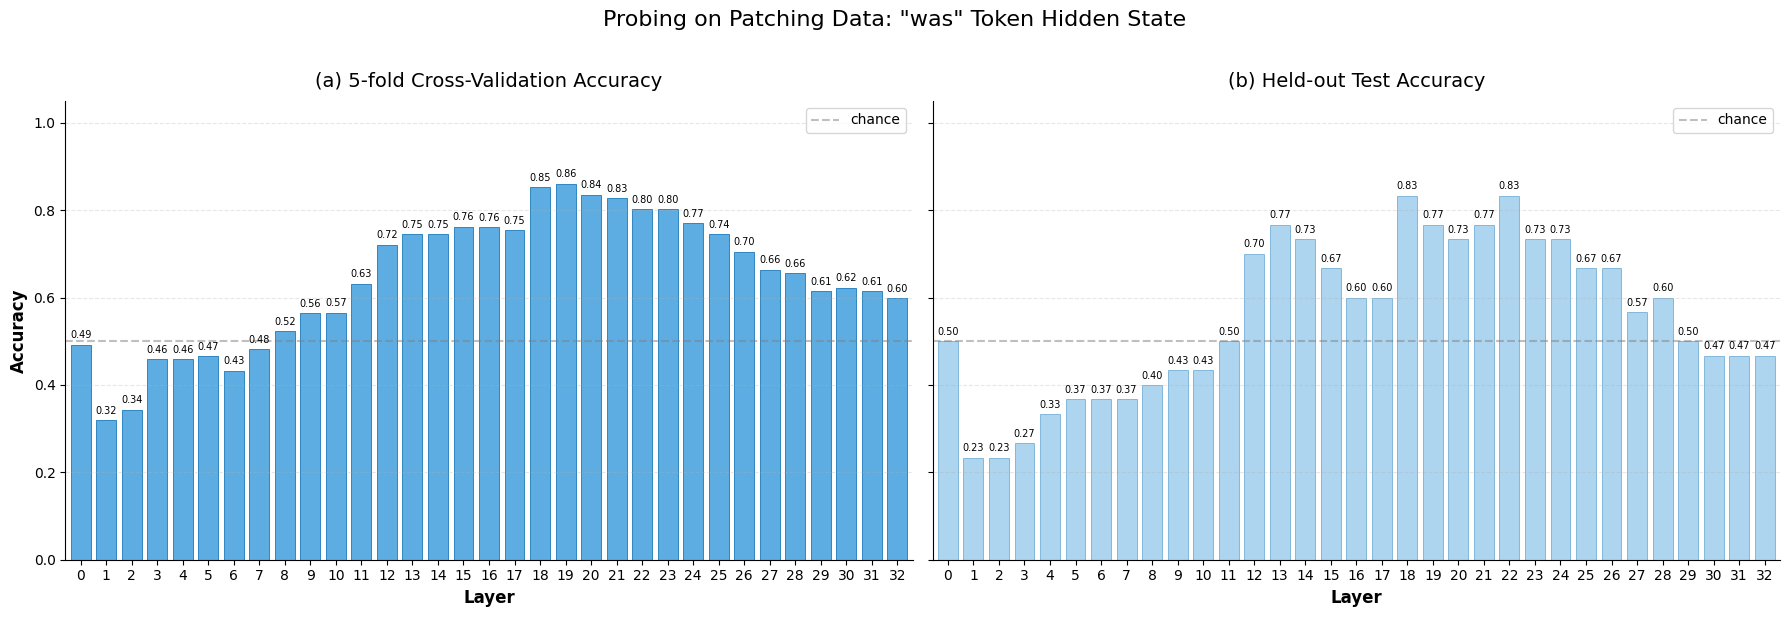

Dataset: 152 examples (122 train, 30 test)
Task: Name1_correct vs Name2_correct at position -1 ("was" token)


In [101]:
layers = sorted(layer_results.keys())
cv_accs = [layer_results[l]['cv_accuracy'] for l in layers]
cv_stds = [layer_results[l]['cv_std'] for l in layers]
test_accs = [layer_results[l]['test_accuracy'] for l in layers]

# ---- Plot 1: CV accuracy with error bars ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

axes[0].bar(
    layers, cv_accs,
    color='#5dade2', edgecolor='#2e86c1', linewidth=0.7, width=0.78,
)
for x, v in zip(layers, cv_accs):
    axes[0].text(x, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
axes[0].set_title('(a) 5-fold Cross-Validation Accuracy', fontsize=14, pad=10)
axes[0].set_xlabel('Layer', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xticks(layers)
axes[0].set_xlim(-0.6, max(layers) + 0.6)
axes[0].set_ylim(0.0, 1.05)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(
    layers, test_accs,
    color='#5dade2', edgecolor='#2e86c1', linewidth=0.7, width=0.78,
    alpha=0.5,
)
for x, v in zip(layers, test_accs):
    axes[1].text(x, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
axes[1].set_title('(b) Held-out Test Accuracy', fontsize=14, pad=10)
axes[1].set_xlabel('Layer', fontsize=12, fontweight='bold')
axes[1].set_xticks(layers)
axes[1].set_xlim(-0.6, max(layers) + 0.6)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Probing on Patching Data: "was" Token Hidden State', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f'Dataset: {n_examples} examples ({n_train} train, {n_test} test)')
print(f'Task: Name1_correct vs Name2_correct at position -1 ("was" token)')

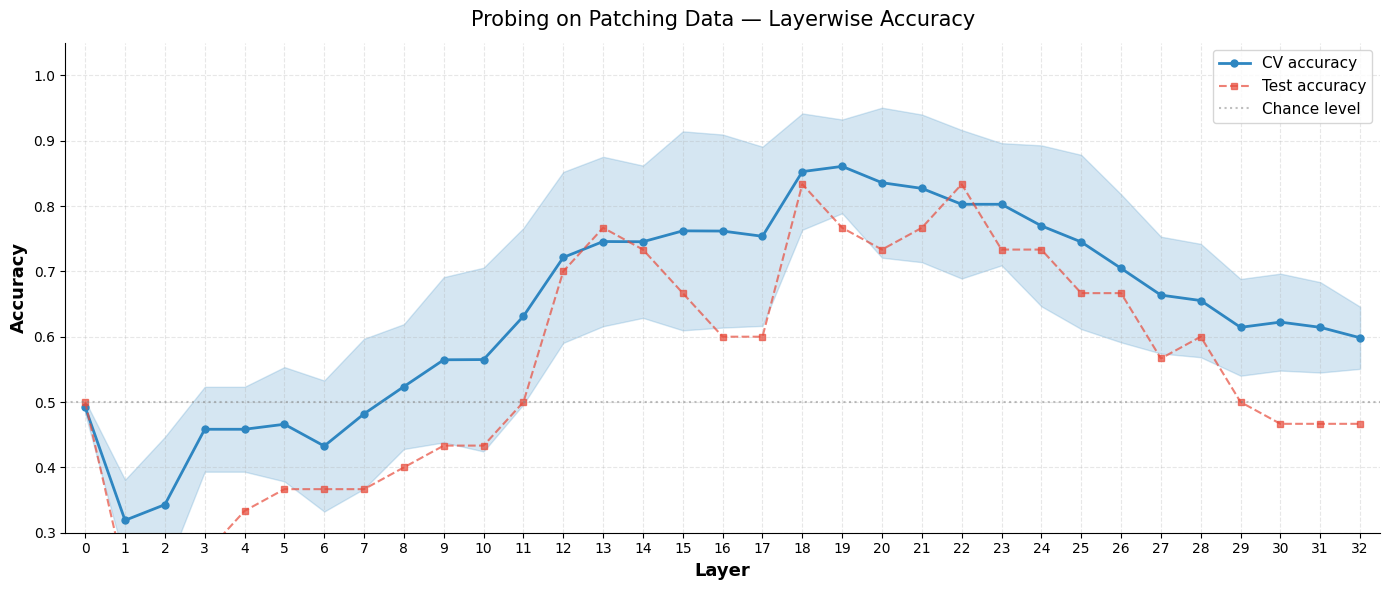

Layer    CV acc    ± std  Test acc
-----------------------------------
    0    0.4920   0.0098    0.5000
    1    0.3190   0.0620    0.2333
    2    0.3430   0.1036    0.2333
    3    0.4583   0.0649    0.2667
    4    0.4583   0.0649    0.3333
    5    0.4660   0.0875    0.3667
    6    0.4327   0.1002    0.3667
    7    0.4820   0.1148    0.3667
    8    0.5237   0.0955    0.4000
    9    0.5647   0.1265    0.4333
   10    0.5650   0.1406    0.4333
   11    0.6313   0.1349    0.5000
   12    0.7213   0.1308    0.7000
   13    0.7457   0.1297    0.7667
   14    0.7453   0.1165    0.7333
   15    0.7620   0.1523    0.6667
   16    0.7617   0.1477    0.6000
   17    0.7537   0.1371    0.6000
   18    0.8527   0.0890    0.8333
   19    0.8607   0.0717    0.7667
   20    0.8357   0.1148    0.7333
   21    0.8270   0.1130    0.7667
   22    0.8027   0.1136    0.8333
   23    0.8027   0.0935    0.7333
   24    0.7697   0.1232    0.7333
   25    0.7450   0.1333    0.6667
   26    0.7047   0

In [97]:
# ---- Plot 2: Line plot for easier comparison with Experiment 1 ----

plt.figure(figsize=(14, 6))
plt.plot(layers, cv_accs, 'o-', color='#2e86c1', linewidth=2, markersize=5, label='CV accuracy')
plt.fill_between(
    layers,
    [a - s for a, s in zip(cv_accs, cv_stds)],
    [a + s for a, s in zip(cv_accs, cv_stds)],
    alpha=0.2, color='#2e86c1',
)
plt.plot(layers, test_accs, 's--', color='#e74c3c', linewidth=1.5, markersize=5, alpha=0.7, label='Test accuracy')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance level')

plt.xlabel('Layer', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.title('Probing on Patching Data — Layerwise Accuracy', fontsize=15, pad=12)
plt.xticks(layers)
plt.xlim(-0.5, max(layers) + 0.5)
plt.ylim(0.3, 1.05)
plt.legend(fontsize=11)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print summary table
print(f'{"Layer":>5s}  {"CV acc":>8s}  {"± std":>7s}  {"Test acc":>8s}')
print('-' * 35)
for l in layers:
    r = layer_results[l]
    print(f'{l:5d}  {r["cv_accuracy"]:8.4f}  {r["cv_std"]:7.4f}  {r["test_accuracy"]:8.4f}')

## 8. Breakdown by Sentence Type

Check whether probing accuracy differs by sentence type (active/passive × agent/patient question).

Sentence types: [np.str_('active_agent'), np.str_('active_patient'), np.str_('passive_agent'), np.str_('passive_patient')]


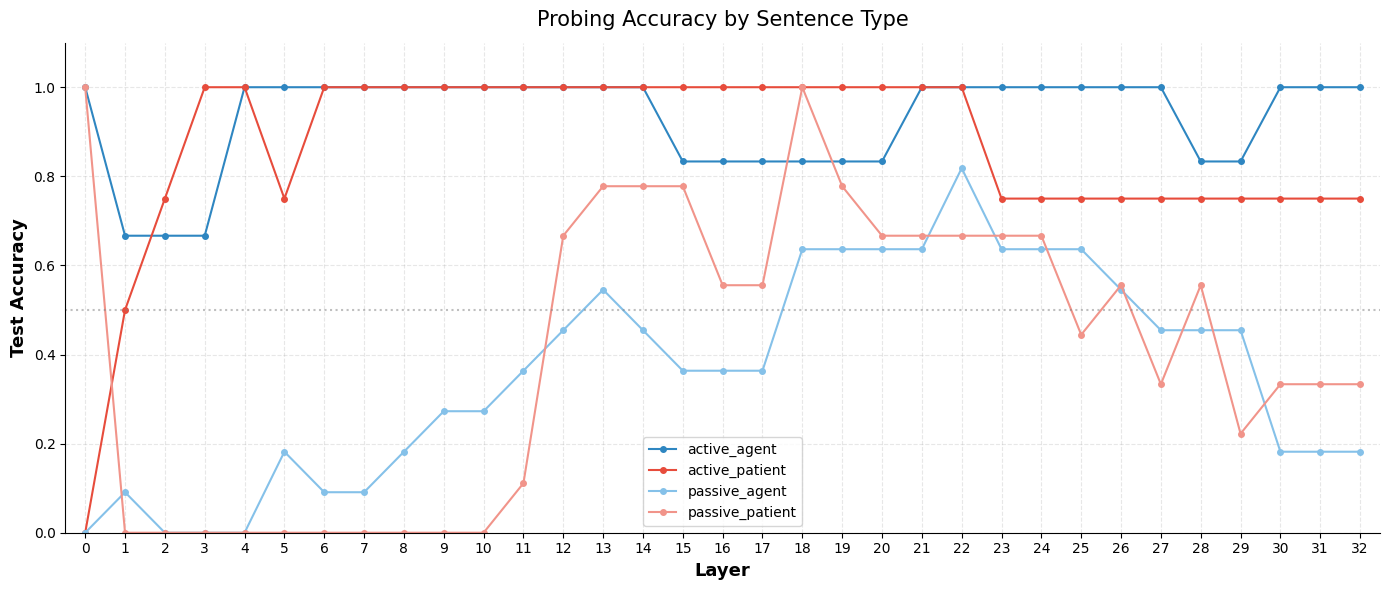

  active_agent: 6 test examples
  active_patient: 4 test examples
  passive_agent: 11 test examples
  passive_patient: 9 test examples


In [98]:
# Map test indices back to sentence types
type_labels = np.array([examples[i]['type'] for i in range(n_examples)])
types = sorted(set(type_labels))
print(f'Sentence types: {types}')

# For each type, compute test accuracy per layer
type_results = {t: {} for t in types}

for layer_idx in range(N_LAYERS + 1):
    X = layer_X[layer_idx]
    X_train, y_train = X[train_idx], y_enc[train_idx]
    
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42, C=c_value),
    )
    clf.fit(X_train, y_train)
    
    for t in types:
        # Test examples of this type
        mask = np.array([type_labels[j] == t for j in test_idx])
        if mask.sum() == 0:
            type_results[t][layer_idx] = float('nan')
            continue
        X_sub = X[test_idx[mask]]
        y_sub = y_enc[test_idx[mask]]
        type_results[t][layer_idx] = float(clf.score(X_sub, y_sub))

# Plot
plt.figure(figsize=(14, 6))
colors = {'active_agent': '#2e86c1', 'passive_agent': '#85c1e9',
          'active_patient': '#e74c3c', 'passive_patient': '#f1948a'}

for t in types:
    accs = [type_results[t].get(l, float('nan')) for l in layers]
    plt.plot(layers, accs, 'o-', label=t, color=colors.get(t, None), linewidth=1.5, markersize=4)

plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Layer', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=13, fontweight='bold')
plt.title('Probing Accuracy by Sentence Type', fontsize=15, pad=12)
plt.xticks(layers)
plt.xlim(-0.5, max(layers) + 0.5)
plt.ylim(0.0, 1.1)
plt.legend(fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Count per type in test set

for t in types:
    count = sum(1 for j in test_idx if type_labels[j] == t)
    print(f'  {t}: {count} test examples')